!python -m pip install --upgrade pip

!pip install git+https://github.com/facebookresearch/segment-anything.git

## Model semantic segmentation
---

In [24]:
#external
import random
import numpy as np

#visualization
import cv2

#model
from src.segment_anything_model import SAMModel
import supervision as sv

#utils
from src.utils.dataset import load_foodseg103_splits

In [29]:
sam_model = SAMModel()

In [26]:
image_dataset = load_foodseg103_splits()["train"]

In [31]:
test_image_idx = random.randint(0, len(image_dataset) - 1)
test_image = np.array(image_dataset[test_image_idx]["image"])
image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
image_rgb.shape

(423, 512, 3)

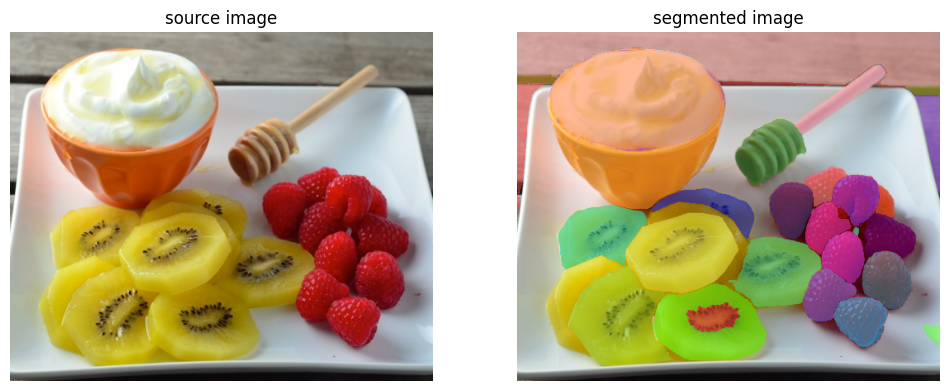

In [33]:
sam_model.preview_image_segmentation(image_rgb, merge_similar=True)

In [34]:
segmentation_masks = sam_model.generate_masks(image_rgb, merge_similar=True)

In [35]:
masks = [
    mask['segmentation']
    for mask
    in sorted(segmentation_masks, key=lambda x: x['area'], reverse=True)
]

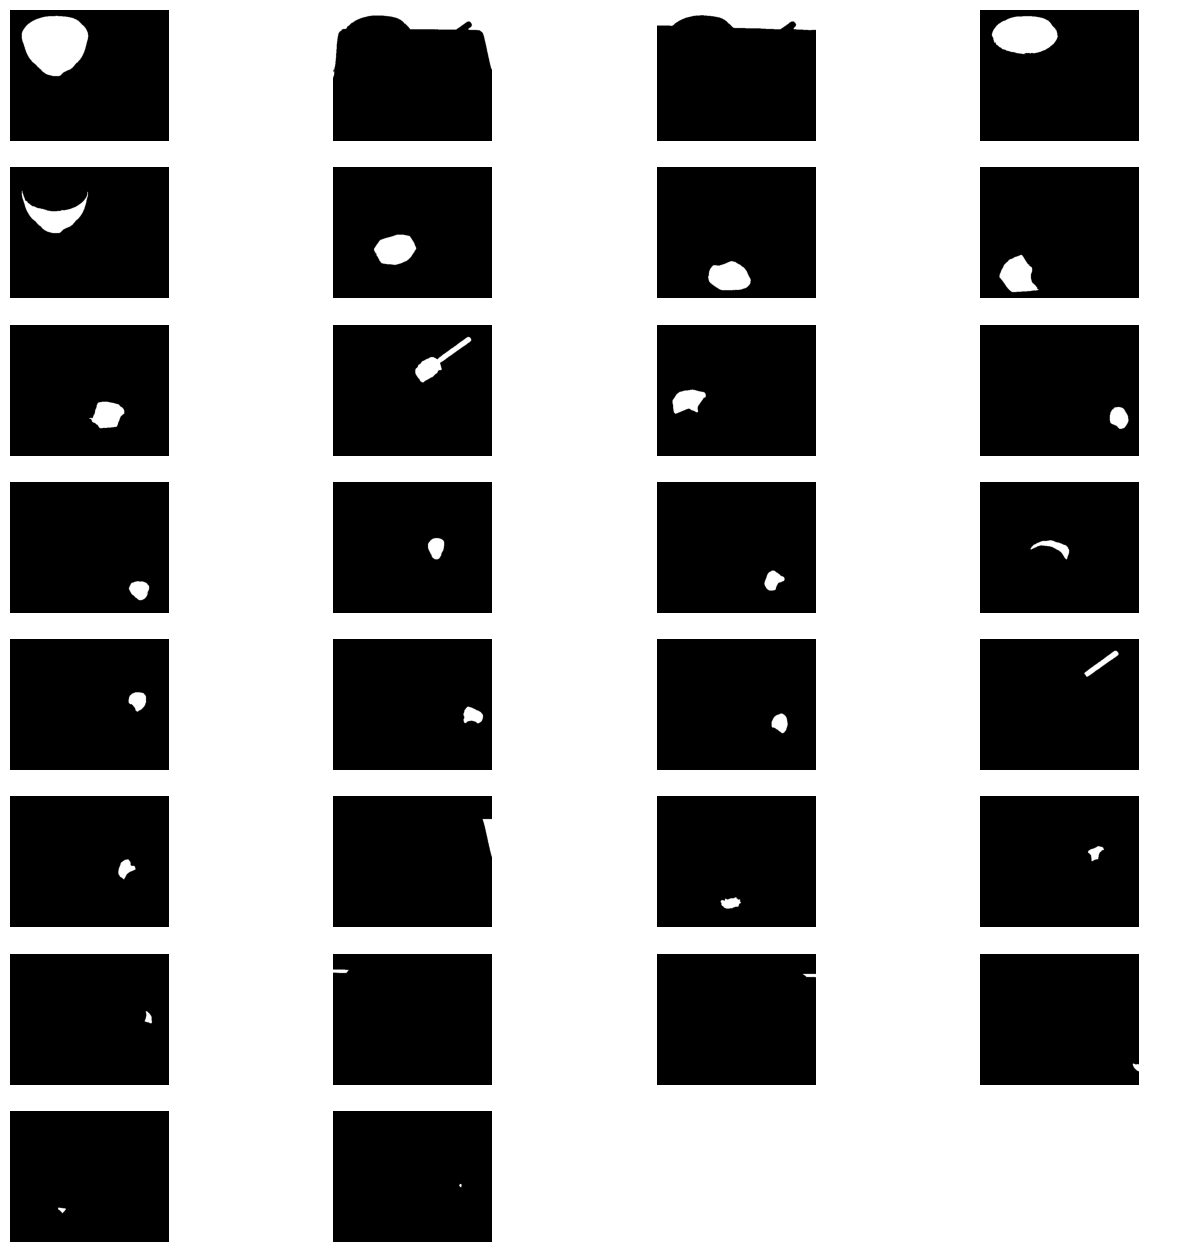

In [36]:
sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks)//8+1)),
    size=(16, 16)
)

### B3 SegFormer
---

In [38]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

In [ ]:
model_path = "nvidia-mit-b3-512x512-epoch=8-val_mean_iou=0.4038-train_mean_iou=0.7578.ckpt"
model = SegformerForSemanticSegmentation.from_pretrained(model_path)

HFValidationError: Repo id must use alphanumeric chars or '-', '_', '.', '--' and '..' are forbidden, '-' and '.' cannot start or end the name, max length is 96: 'nvidia-mit-b3-512x512-epoch=8-val_mean_iou=0.4038-train_mean_iou=0.7578.ckpt'.

## References

[1] https://blog.roboflow.com/how-to-use-segment-anything-model-sam/